<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Variations: Natal kicks</p>
    <o style='font-size:20px;'>This notebook handles plots for the natal kick variations</p>
</div>

In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [3]:
reload(constants)
files = ["fiducial", 'bhflag_3', 'bhflag_0']
labels = ["Fiducial", "No fallback scaling", "No BH kicks"]    
colours = [constants.FILE_TO_COLOUR[f] for f in files]

In [4]:
pops, data = helpers.load_postprocessed_pops(files, labels, colours)

Loading post-processed data for Fiducial from fiducial
Loading post-processed data for No fallback scaling from bhflag_3
Loading post-processed data for No BH kicks from bhflag_0


In [5]:
linestyles = ["-", ":", "-"]
for i, pop in enumerate(pops):
    pop.linestyle = linestyles[i]

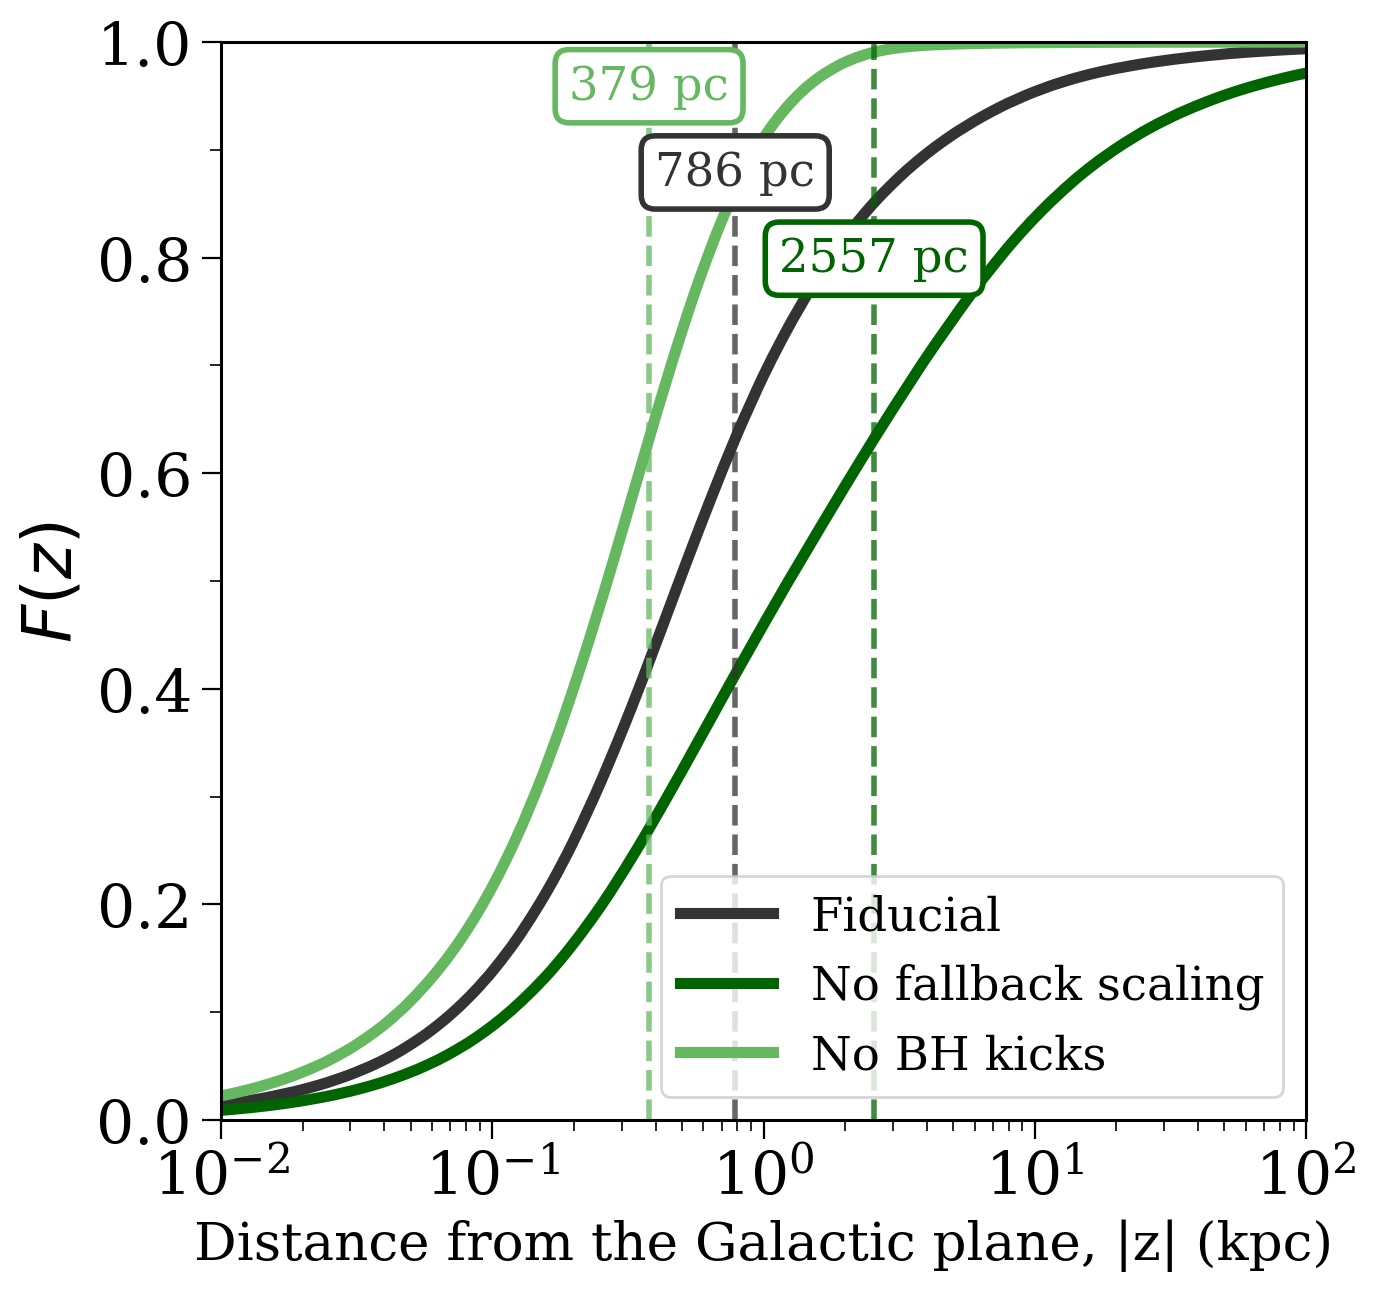

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for pop, loc in zip(pops, [0.98 - 0.08 * 1, 0.98 - 0.08 * 2, 0.98 - 0.08 * 0]):

    plotting.estimate_scale_height_cdf(
        z=data[pop.label]["pos"]["BH"][:, 2][~data[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e2),
        ylim=(0, 1),
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_kicks.pdf", format="pdf", bbox_inches='tight')

plt.show()

In [7]:
print("Average BH masses:")
print("------------------")

for pop in pops:
    mass = data[pop.label]["mass"]

    average_escaped_BH_mass = np.mean(mass["BH"][data[pop.label]["escaped"]["BH"]])
    average_bound_BH_mass = np.mean(mass["BH"][~data[pop.label]["escaped"]["BH"]])

    avg_bound_BH_close_to_disc = np.mean(mass["BH"][(
        ~data[pop.label]["escaped"]["BH"] &
        (abs(data[pop.label]["pos"]["BH"][:, 2]) < 1)
    )])

    avg_bound_BH_far_from_disc = np.mean(mass["BH"][(
        ~data[pop.label]["escaped"]["BH"] &
        (abs(data[pop.label]["pos"]["BH"][:, 2]) >= 1)
    )])

    print(f"{pop.label}")
    print(f"  Escaped: {average_escaped_BH_mass:.1f} Msun")
    print(f"  Bound:   {average_bound_BH_mass:.1f} Msun")
    print(f"    Close to disc (<1 kpc):  {avg_bound_BH_close_to_disc:.1f} Msun")
    print(f"    Far from disc (>=1 kpc): {avg_bound_BH_far_from_disc:.1f} Msun")
    print()

Average BH masses:
------------------
Fiducial
  Escaped: 5.1 Msun
  Bound:   8.8 Msun
    Close to disc (<1 kpc):  9.4 Msun
    Far from disc (>=1 kpc): 7.4 Msun

No fallback scaling
  Escaped: 9.2 Msun
  Bound:   8.6 Msun
    Close to disc (<1 kpc):  7.9 Msun
    Far from disc (>=1 kpc): 9.2 Msun

No BH kicks
  Escaped: 4.1 Msun
  Bound:   8.6 Msun
    Close to disc (<1 kpc):  8.5 Msun
    Far from disc (>=1 kpc): 9.8 Msun



In [10]:
reload(helpers)
z_range = np.geomspace(0.05, 10, 250)

init_abs_z = np.abs(data[pops[0].label]["init_z"]["BH"])

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(data[pop.label]["pos"]["BH"][:, 2]) for pop in pops] + [init_abs_z],
    bh_masses=[data[pop.label]["mass"]["BH"] for pop in pops] + [data[pops[0].label]["mass"]["BH"]],
    z_range=z_range,
    window_width=0.25,
    average_function=np.median
)

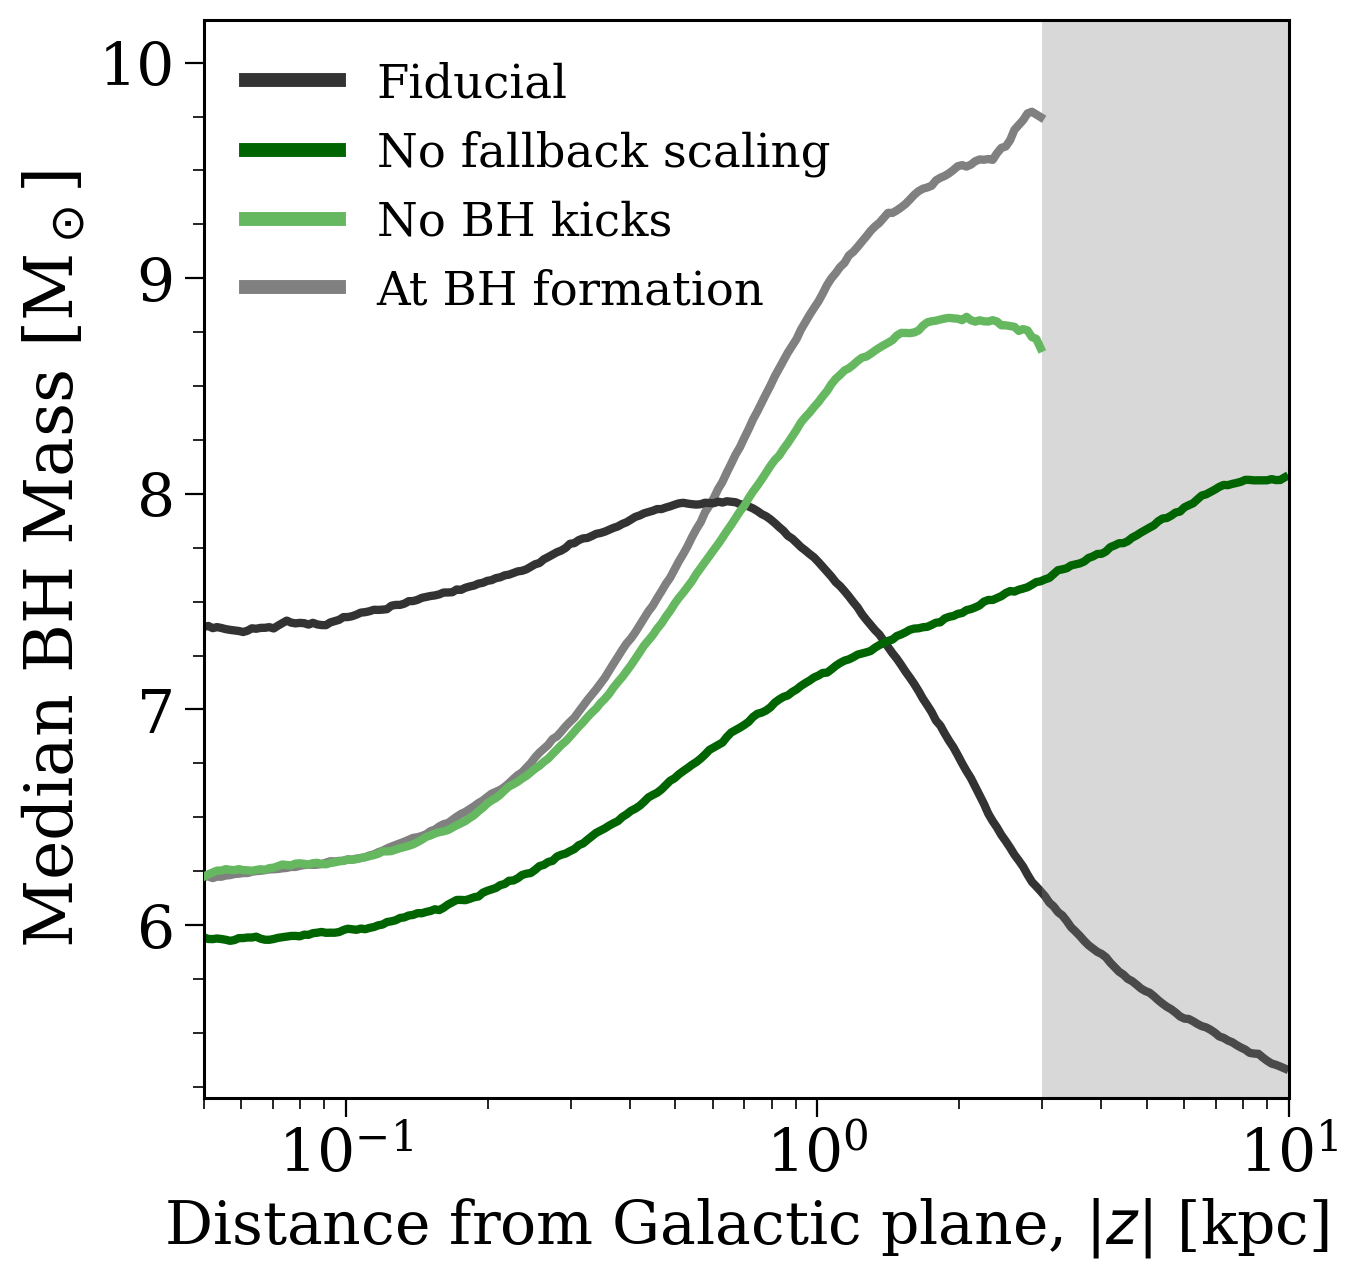

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Median BH Mass [M$_\\odot$]'>)

In [11]:
reload(plotting)

z_maxes = [10, 10, 3, 3]
plotting.plot_avg_mass_vs_z(
    mean_masses=mean_masses,
    labels=labels + ["At BH formation"],
    colours=colours + ["grey"],
    z_maxes=z_maxes,
    z_range=z_range,
    zorders=[1, 2, 3, 0],
    legend_kwargs={
        "title": None,
        "fontsize": 0.7*fs,
        "title_fontsize": 0.6*fs,
        "loc": "upper left",
        "frameon": False
    },
    ax_kwargs={
        "ylim": (5.2, 10.2),
    },
    save="../plots/average_bh_mass_vs_z_kicks.pdf",
)

# Scratch below

7.187657556599623 4.3774123707405135


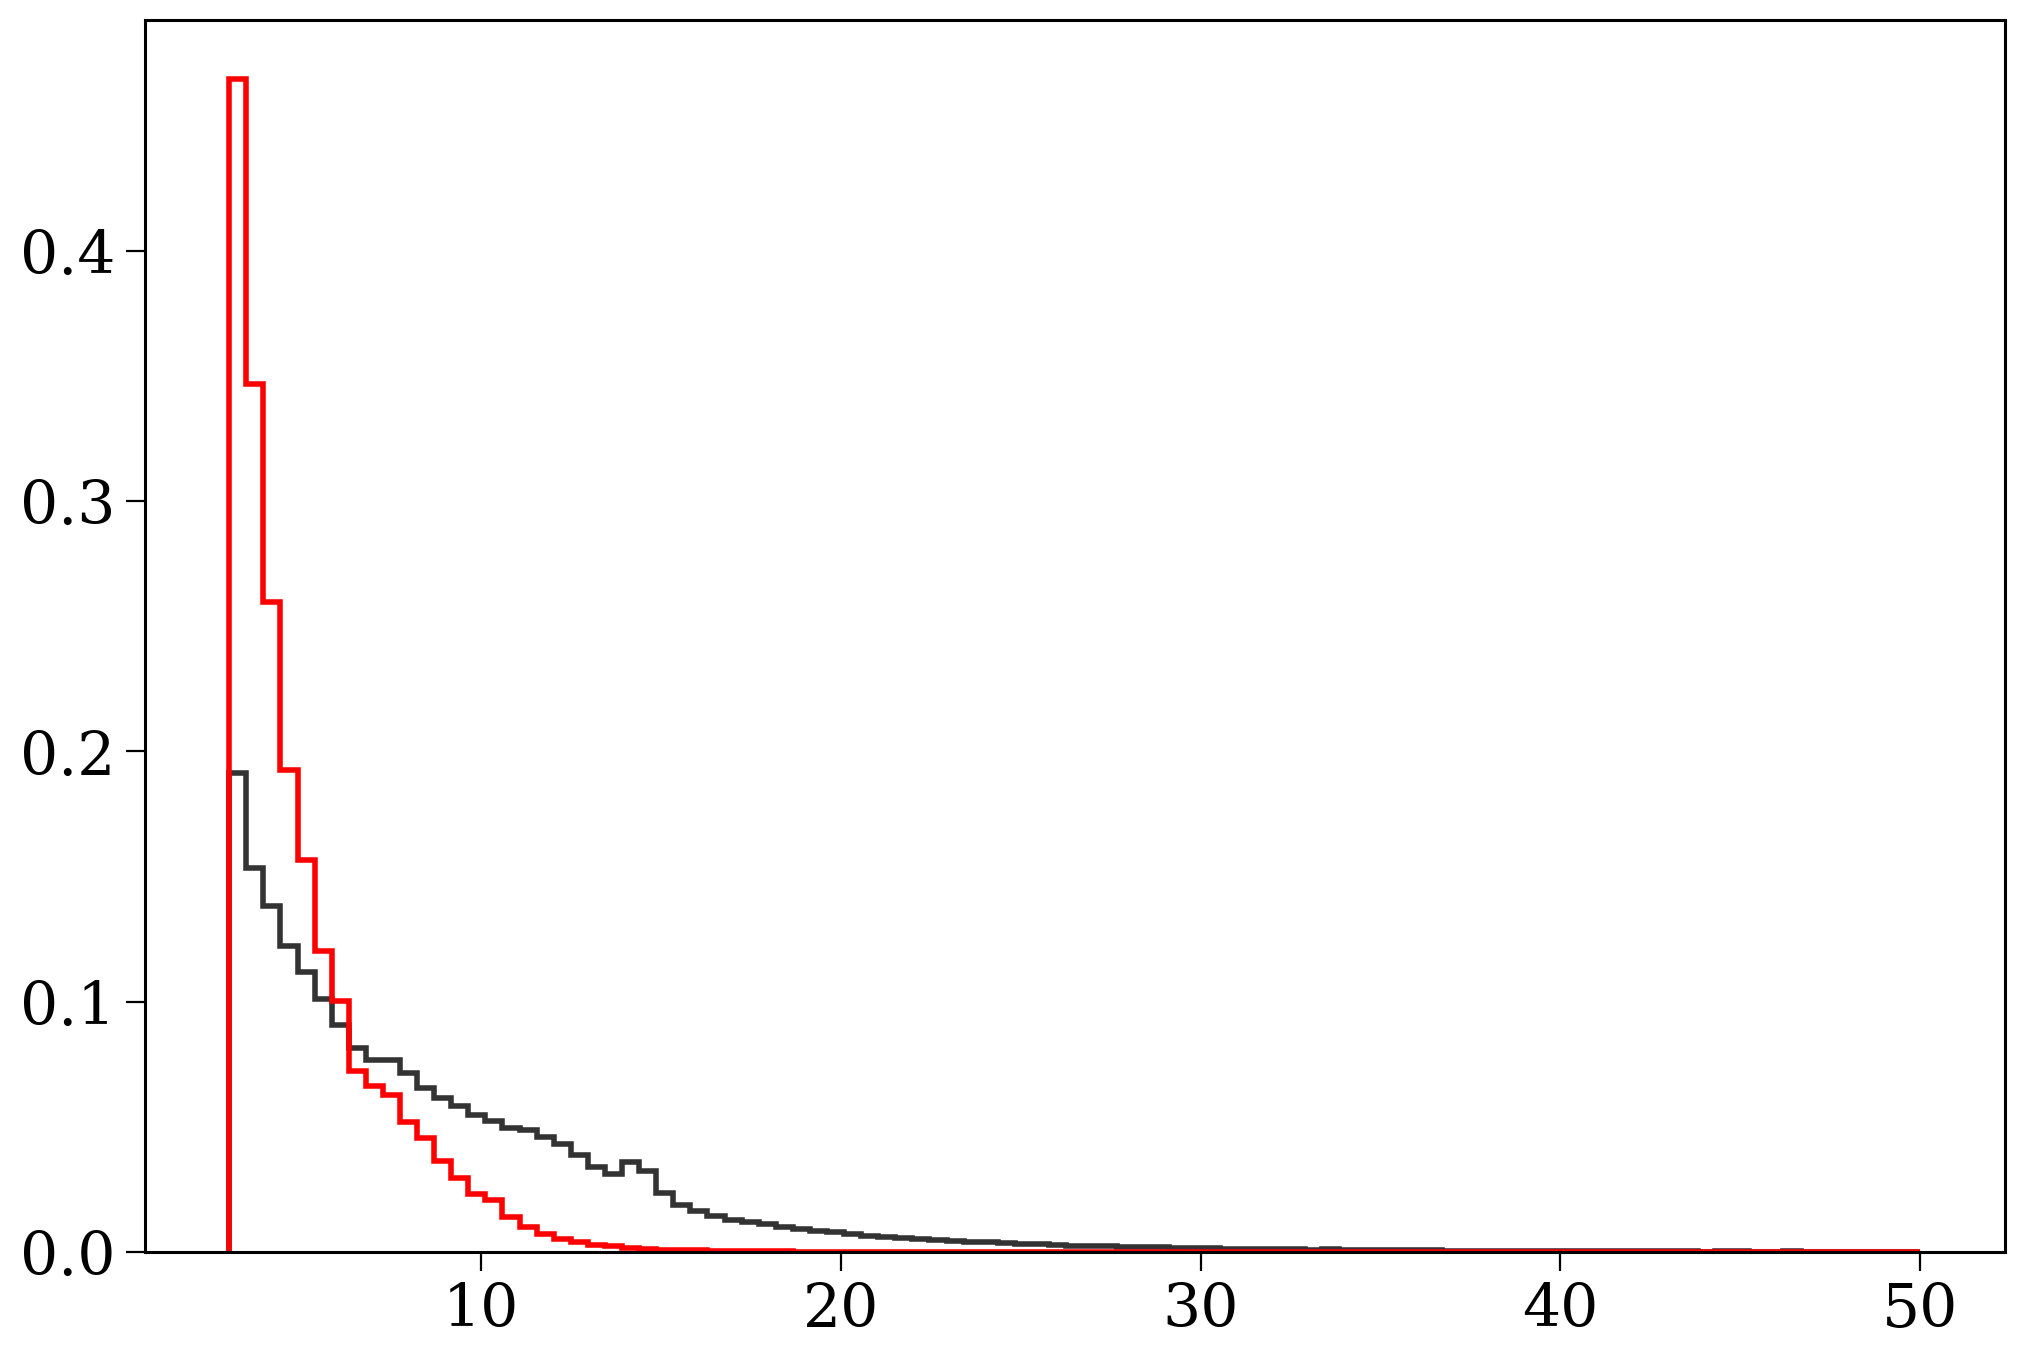

7.085802300248151 7.704164239017912


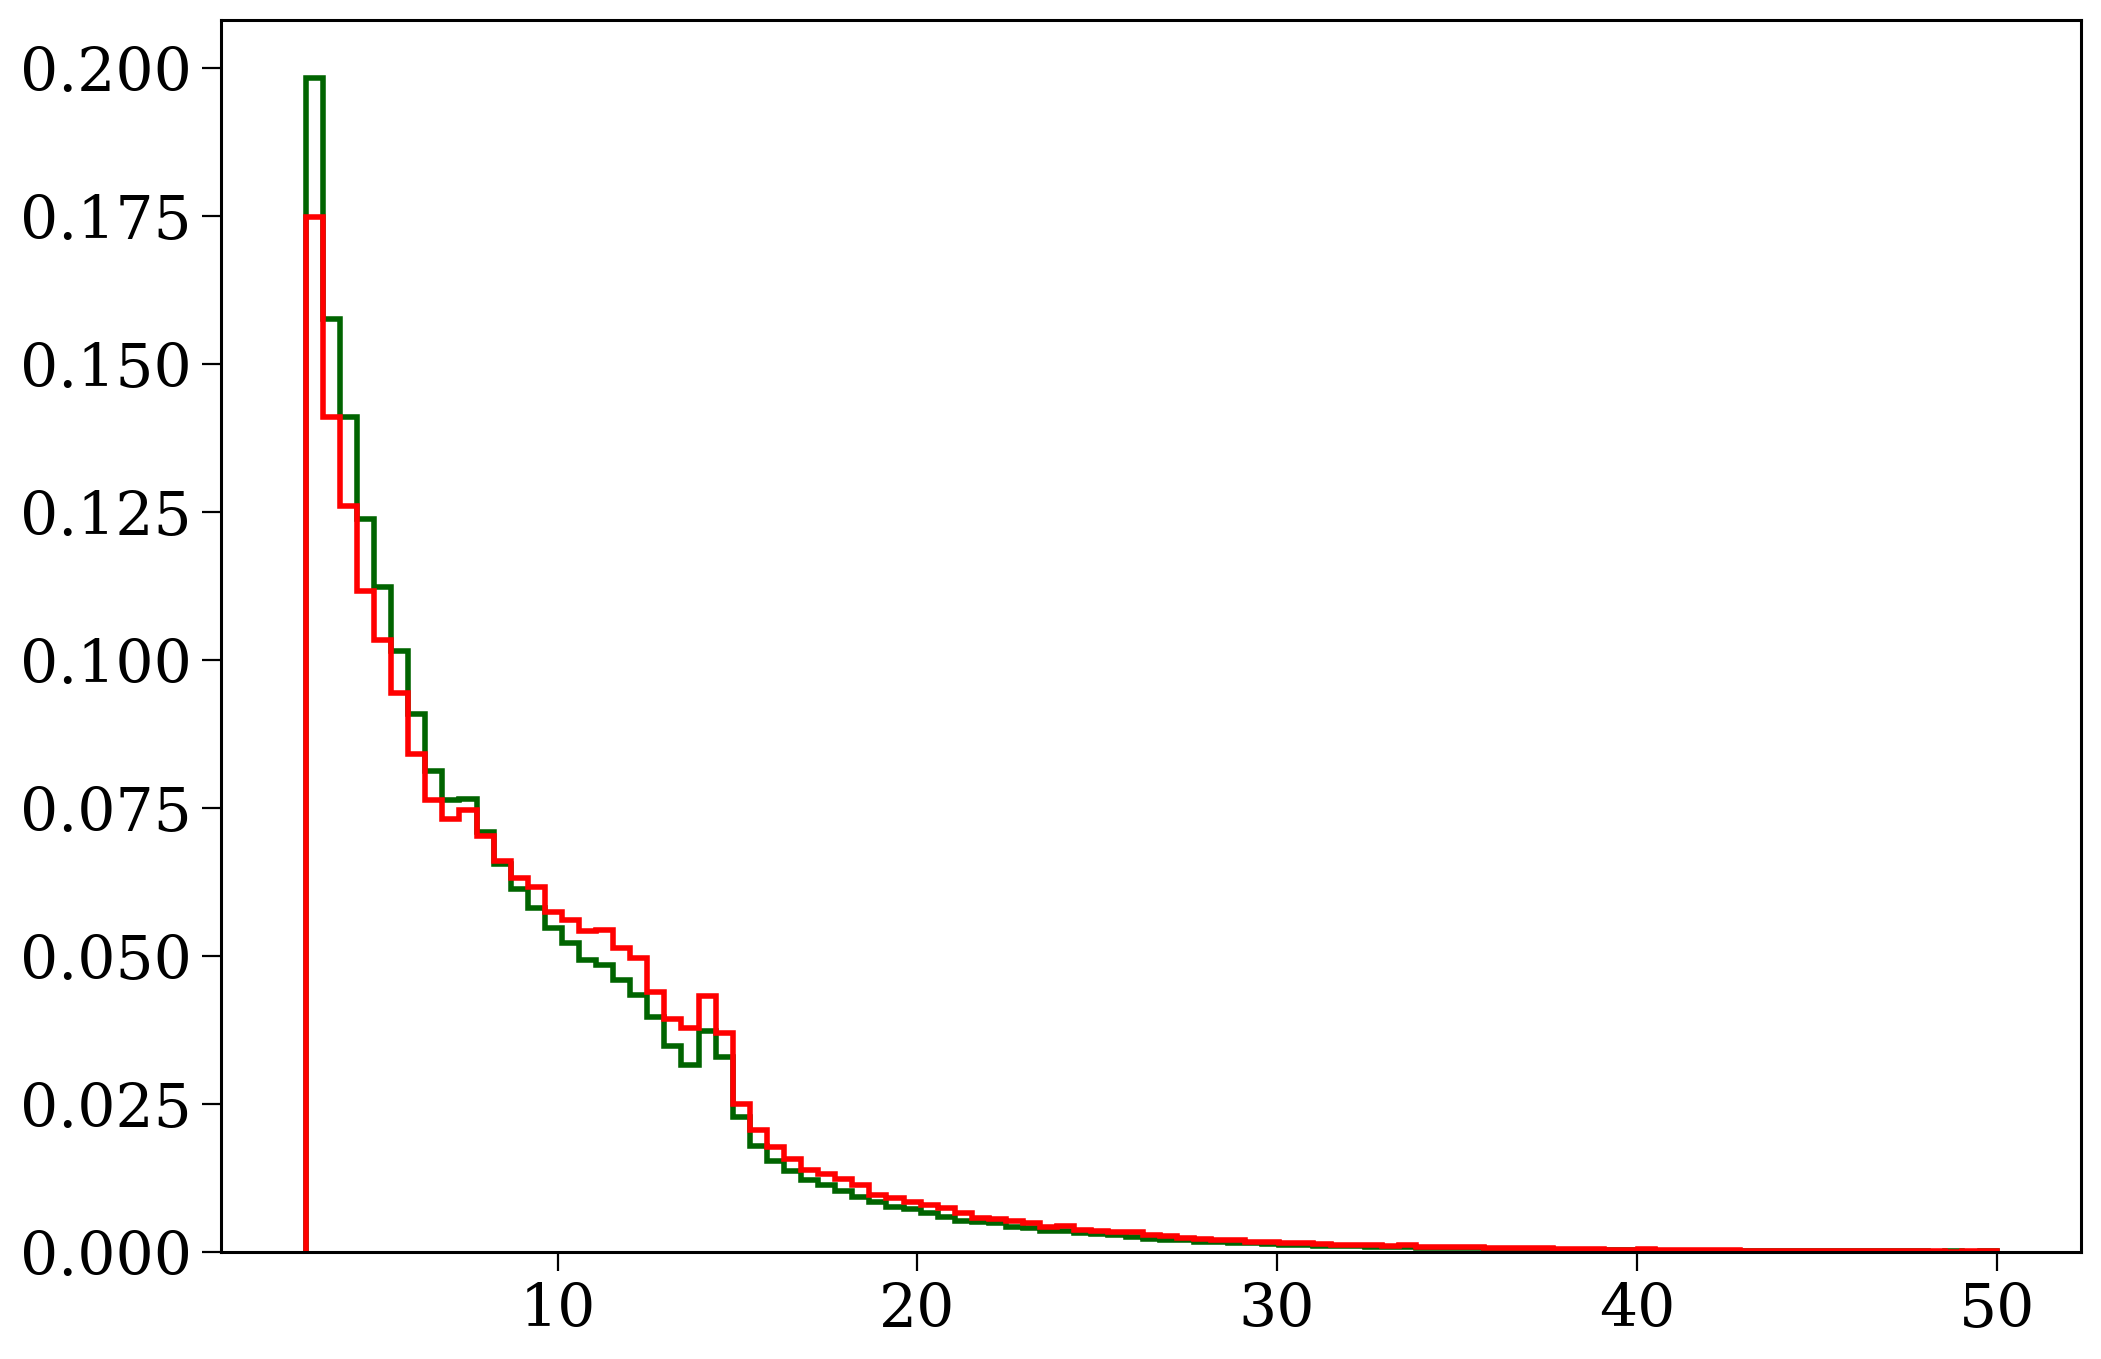

6.988287600983968 3.530244453977195


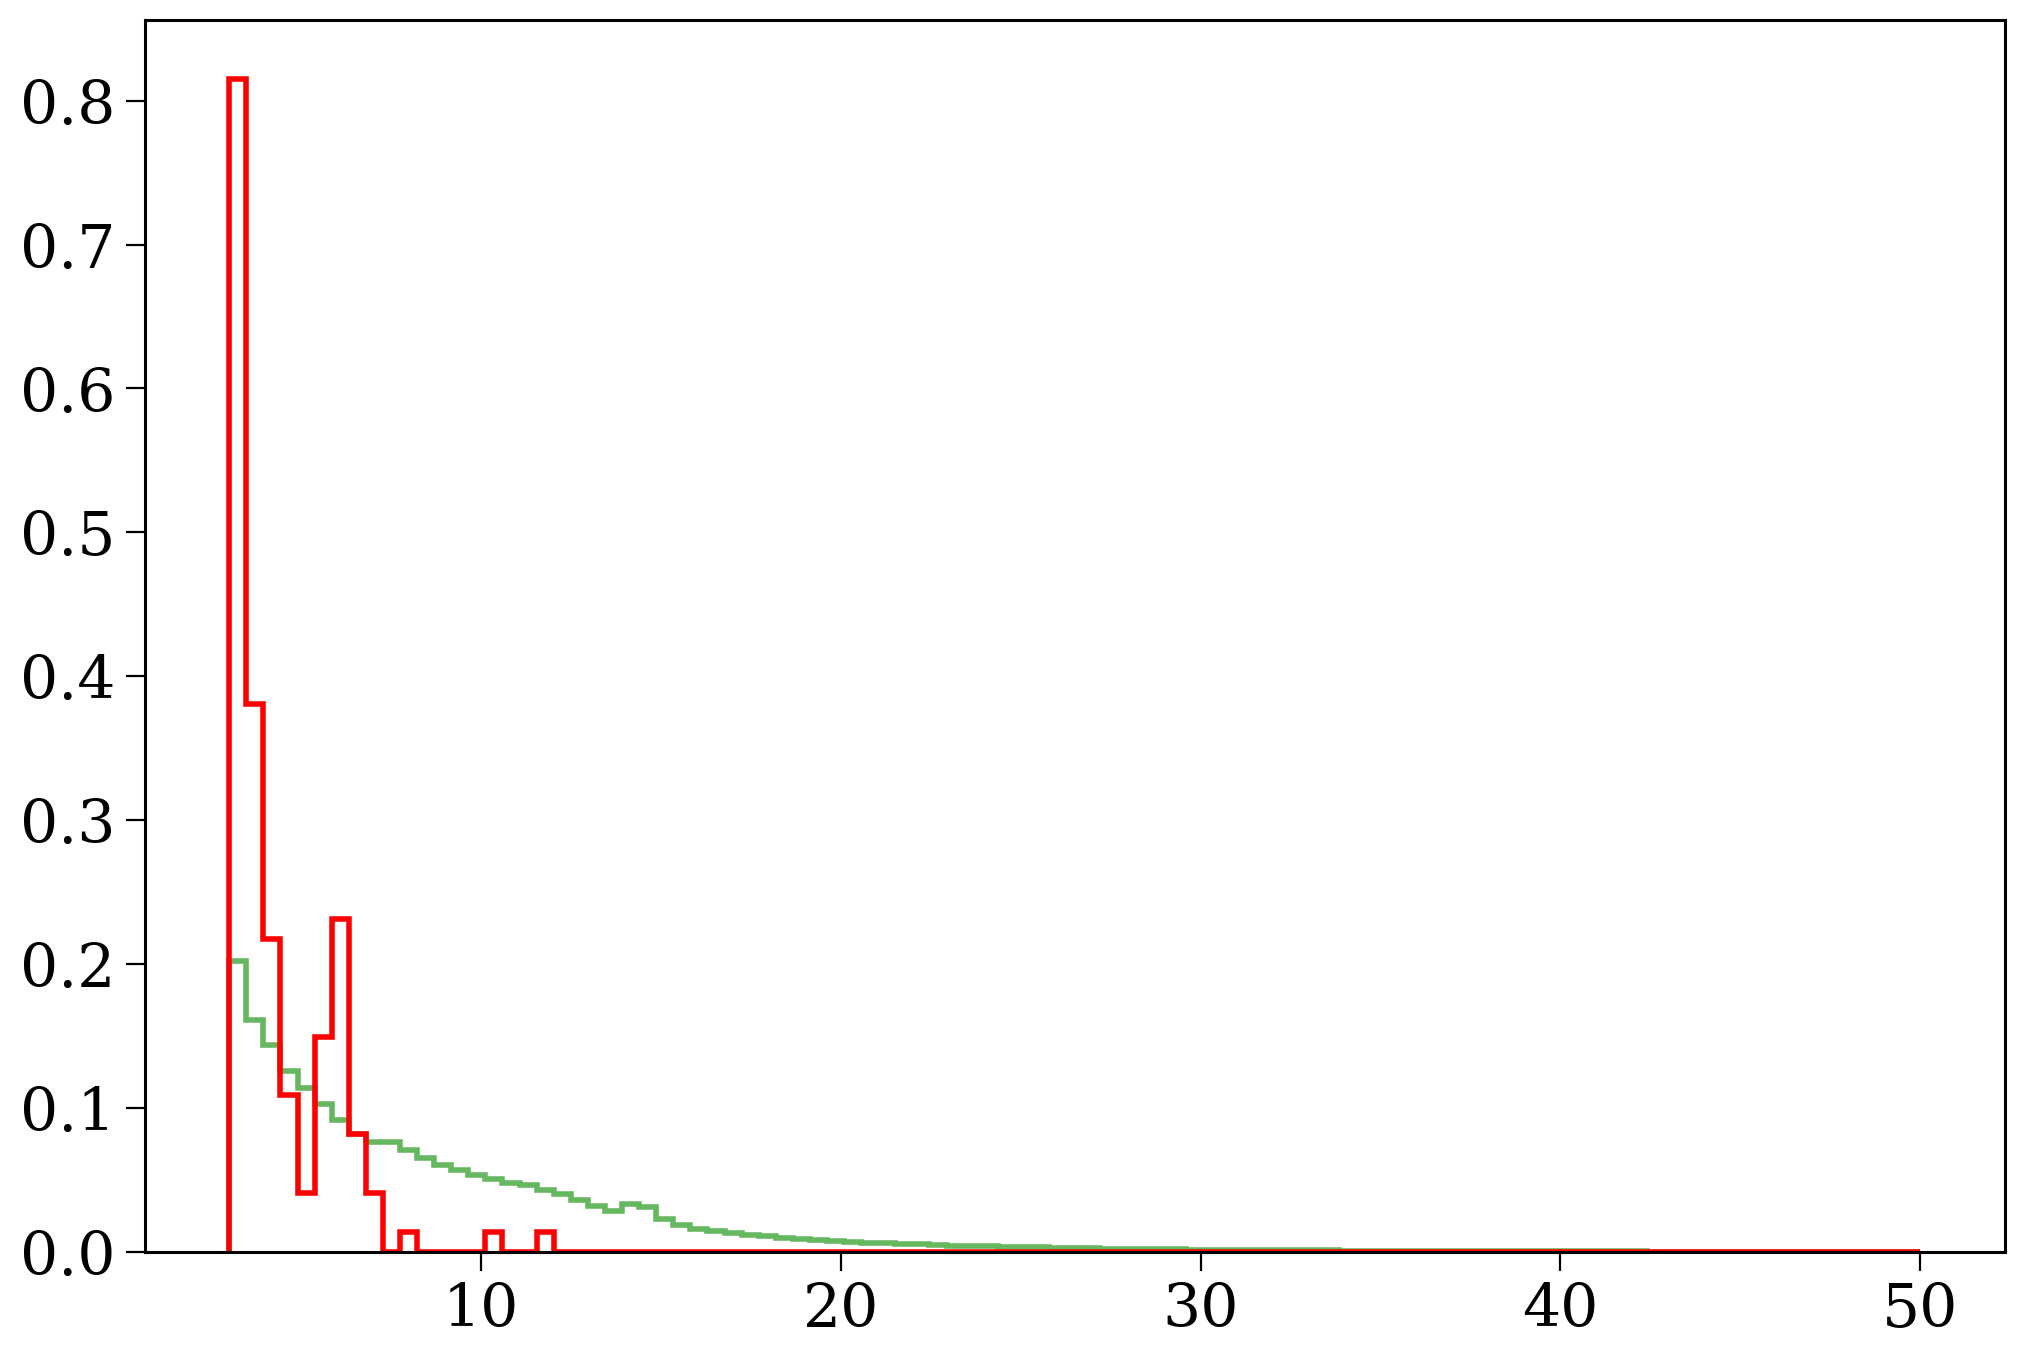

In [114]:
for pop in pops:
    plt.hist(data[pop.label]["mass"]["BH"][~data[pop.label]["escaped"]["BH"]], bins=np.linspace(3, 50, 100), histtype="step", label=pop.label, color=pop.colour, lw=2, density=True)
    plt.hist(data[pop.label]["mass"]["BH"][data[pop.label]["escaped"]["BH"]], bins=np.linspace(3, 50, 100), histtype="step", label=pop.label, color="red", lw=2, density=True)
    print(np.median(data[pop.label]["mass"]["BH"][~data[pop.label]["escaped"]["BH"]]), np.median(data[pop.label]["mass"]["BH"][data[pop.label]["escaped"]["BH"]]))
    plt.show()

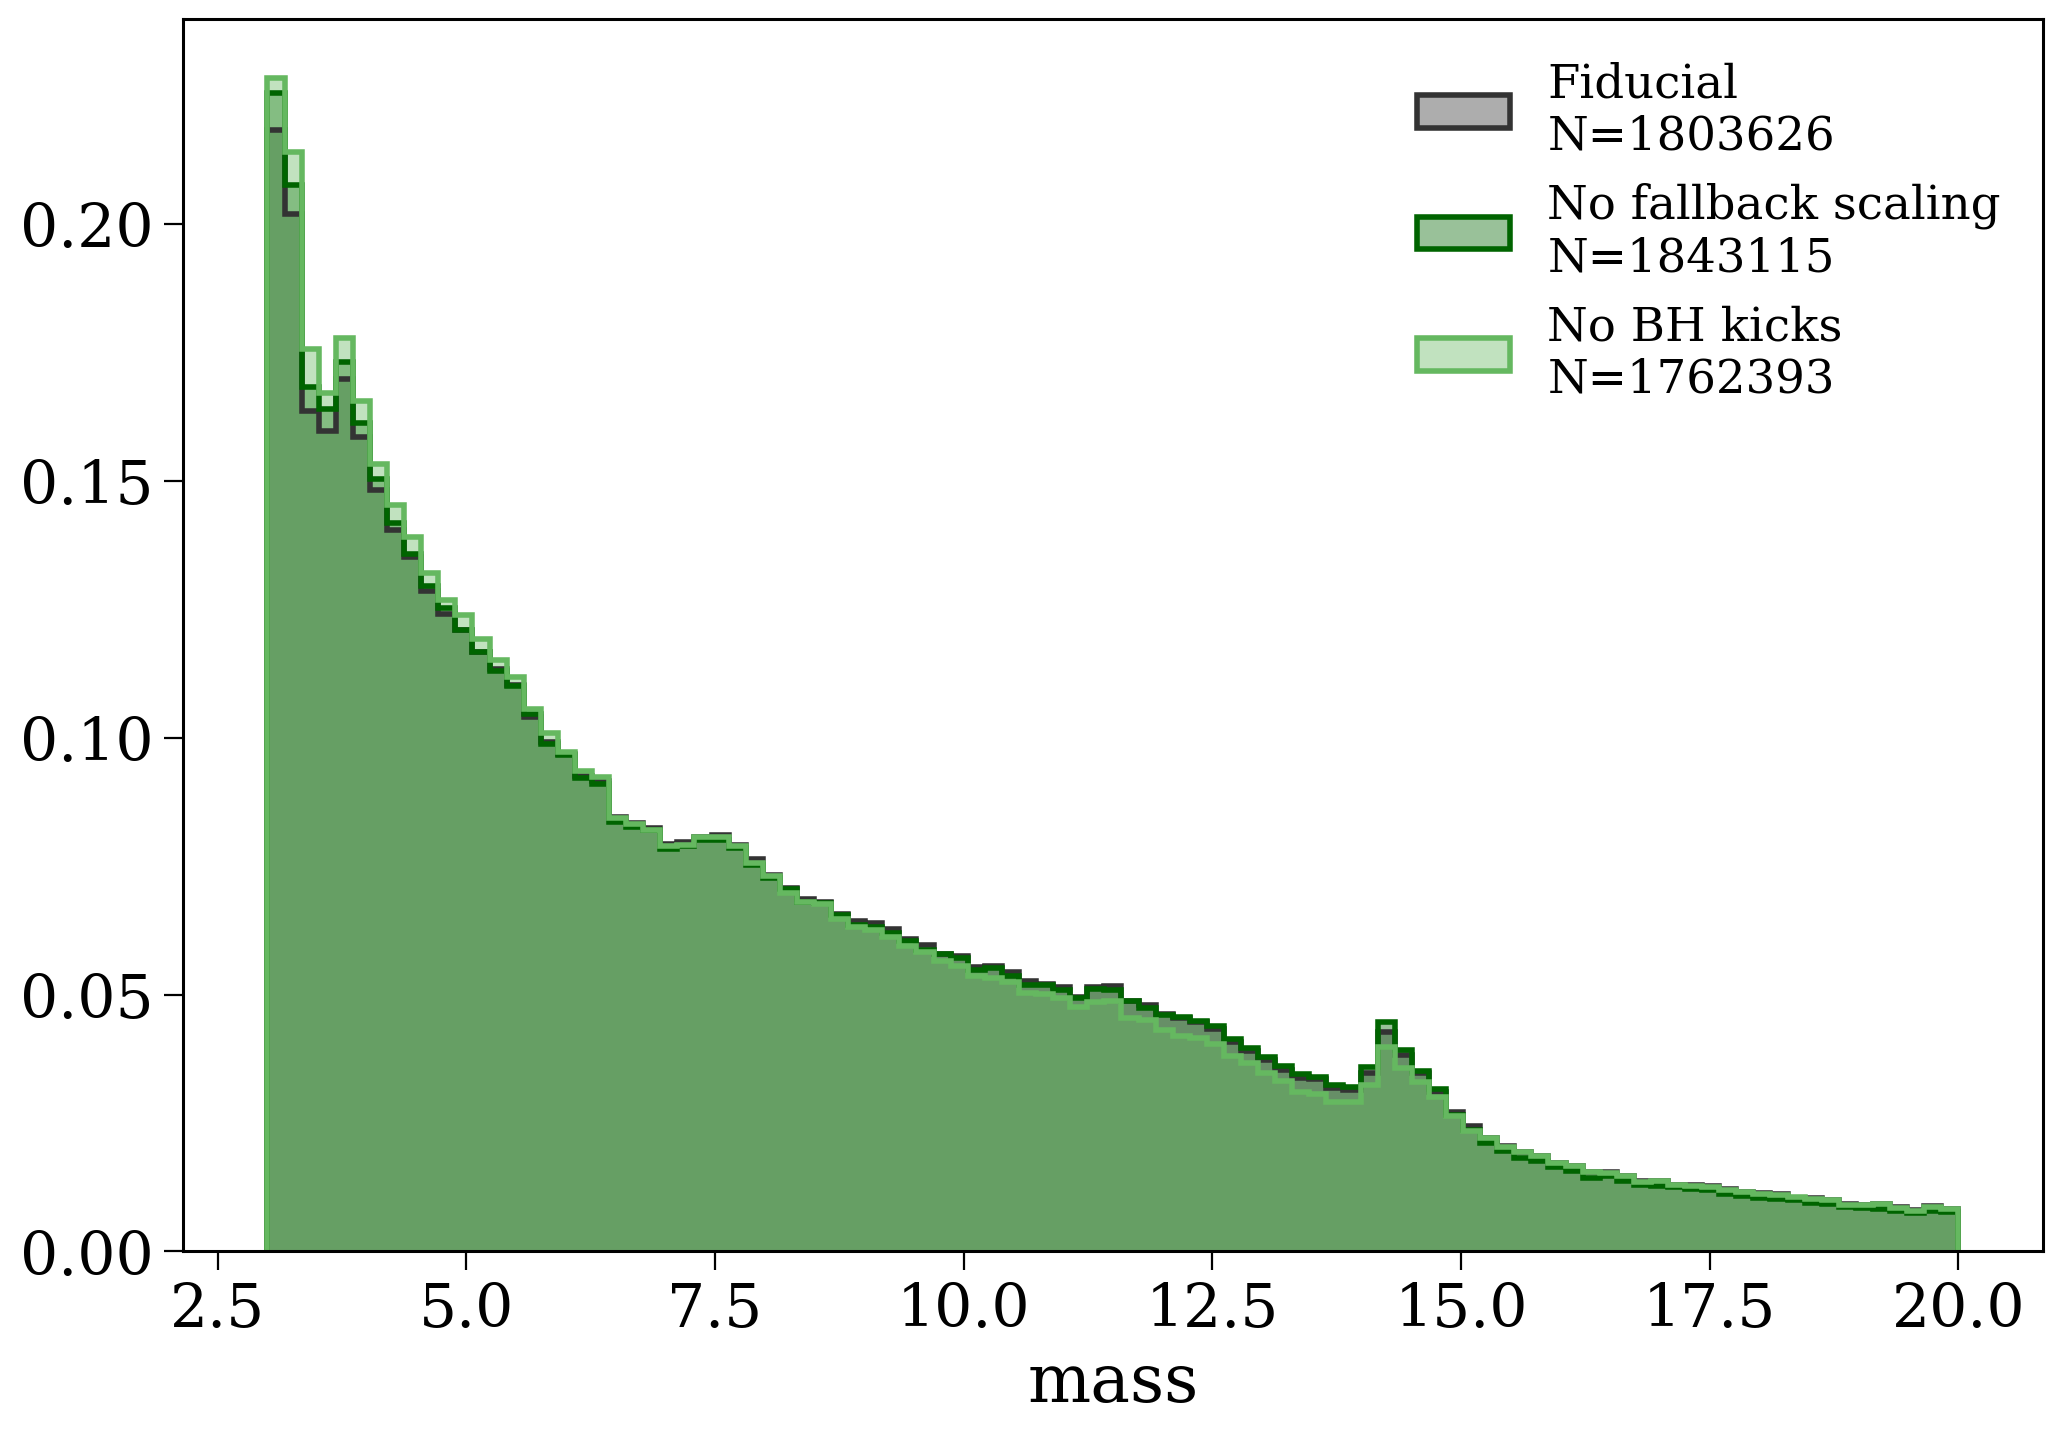

(<Figure size 1200x800 with 1 Axes>, <Axes: xlabel='mass'>)

In [33]:
plotting.plot_mass_histogram(
    pops, data, bins=np.linspace(3, 20, 100), co_type="BH", xlabel="mass", ylabel=None,
)

In [99]:
no_kicks = helpers.load_distributed_pop(
    base_path="/mnt/ceph/users/twagg/underworld/sims",
    sim_name="bhflag_0",
    parts=10,
    colour=colours[0],
    label=labels[0]
)

Loading distributed population Fiducial from 10 parts
   loaded part 1/10 of Fiducial with 165709 binaries
   loaded part 2/10 of Fiducial with 165987 binaries
   loaded part 3/10 of Fiducial with 165382 binaries
   loaded part 4/10 of Fiducial with 165803 binaries
   loaded part 5/10 of Fiducial with 165548 binaries
   loaded part 6/10 of Fiducial with 166601 binaries
   loaded part 7/10 of Fiducial with 165863 binaries
   loaded part 8/10 of Fiducial with 166077 binaries
   loaded part 9/10 of Fiducial with 166187 binaries


cogsworth warning: You have not provided any binary stellar evolution (BSE) settings. You must provide either `BSE_settings` or an `ini_file` in order to perform stellar evolution with COSMIC. You may set `use_default_BSE_settings=True` to use the default settings listed in cogsworth, but do so at your own risk and be sure to understand the choices that you have made.
Run `cogsworth.utils.list_BSE_defaults()` to see these.


   loaded part 10/10 of Fiducial with 166357 binaries


In [100]:
disrupted_ones = no_kicks.final_bpp[((no_kicks.final_bpp["kstar_2"] == 14)) & (no_kicks.final_bpp["sep"] < 0)]["bin_num"]

In [101]:
no_kicks.final_bpp.loc[disrupted_ones][["kstar_1", "kstar_2"]].value_counts()

kstar_1  kstar_2
13       14         116322
14       14           2743
11       14              2
Name: count, dtype: int64

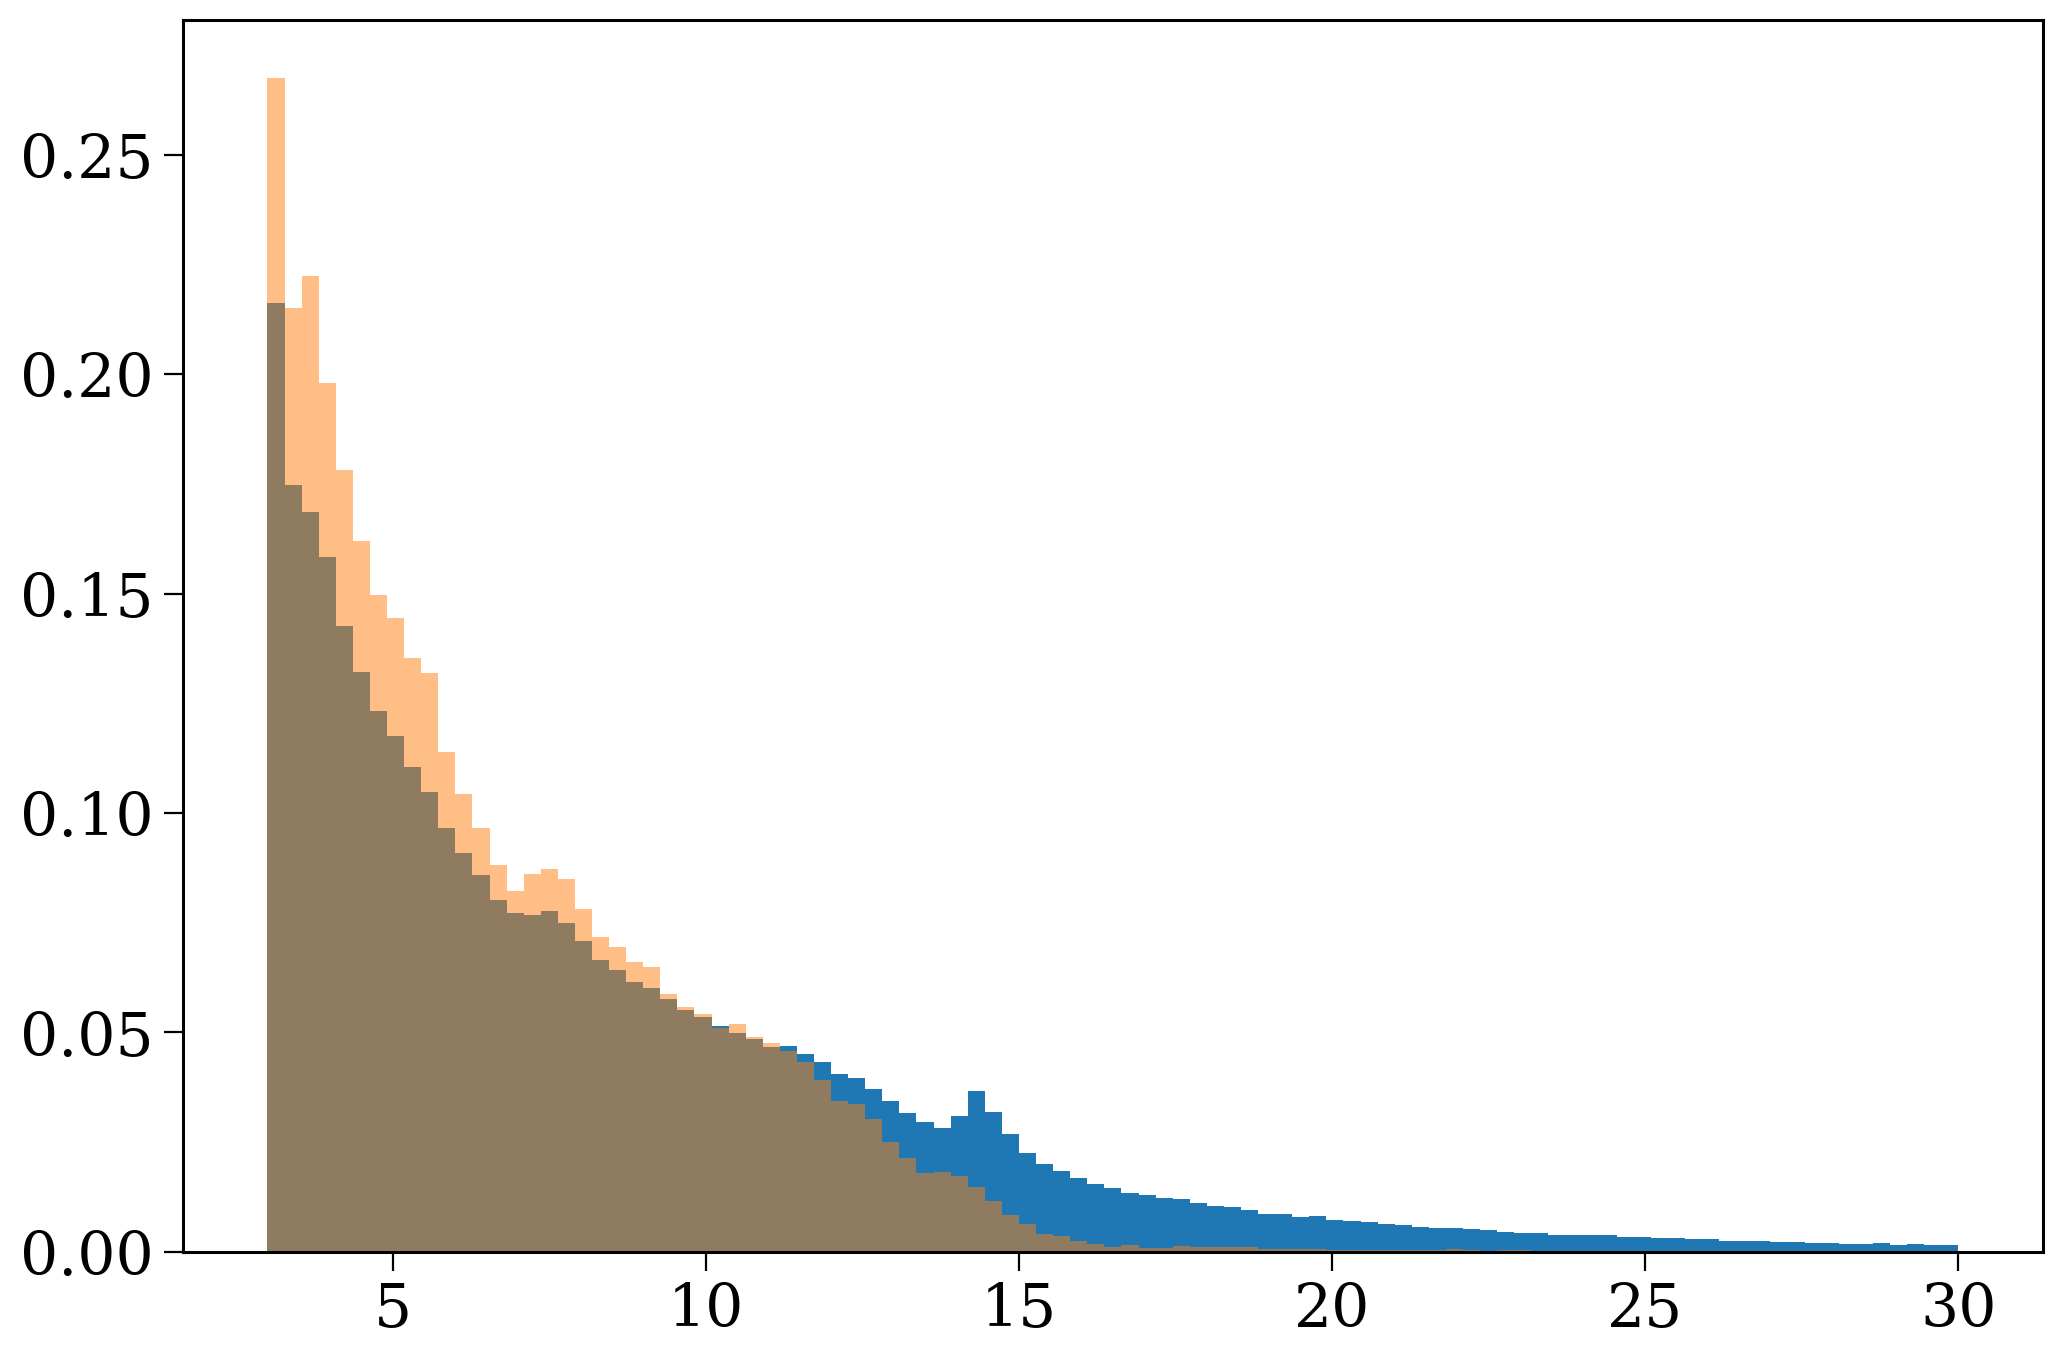

In [105]:
plt.hist(data["No BH kicks"]["mass"]["BH"], bins=np.linspace(3, 30, 100), density=True);
plt.hist(no_kicks.final_bpp.loc[disrupted_ones]["mass_2"], bins=np.linspace(3, 30, 100), density=True, alpha=0.5);

(array([ 51.,  71.,  57.,  84., 256., 439., 643., 726., 686., 711., 611.,
        625., 588., 538., 491., 450., 447., 436., 408., 361., 353., 349.,
        262., 277., 263., 211., 195., 172., 157., 136.,  88.,  71.,  82.,
         75.,  62.,  39.,  42.,  22.,  21.,  30.,  18.,  15.,  15.,   9.,
         13.,  10.,  11.,  11.,   7.,   3.,   3.,   4.,   4.,   2.,   2.,
          1.,   0.,   0.,   0.,   2.,   1.,   1.,   1.,   0.,   0.,   1.,
          1.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,
          0.,   1.,   0.,   0.,   1.,   0.,   0.,   1.]),
 array([  0.30638212,   1.56031018,   2.81423824,   4.06816631,
          5.32209437,   6.57602243,   7.8299505 ,   9.08387856,
         10.33780662,  11.59173469,  12.84566275,  14.09959082,
         15.35351888,  16.60744694,  17.86137501,  19.11530307,
         20.36923113,  21.6231592 ,  22.87708726,  24.13101532,
         25.38494339,  26.63887145,  27.89279951,  29.14672758,
         30.40065564,  31.6545837 ,  32.

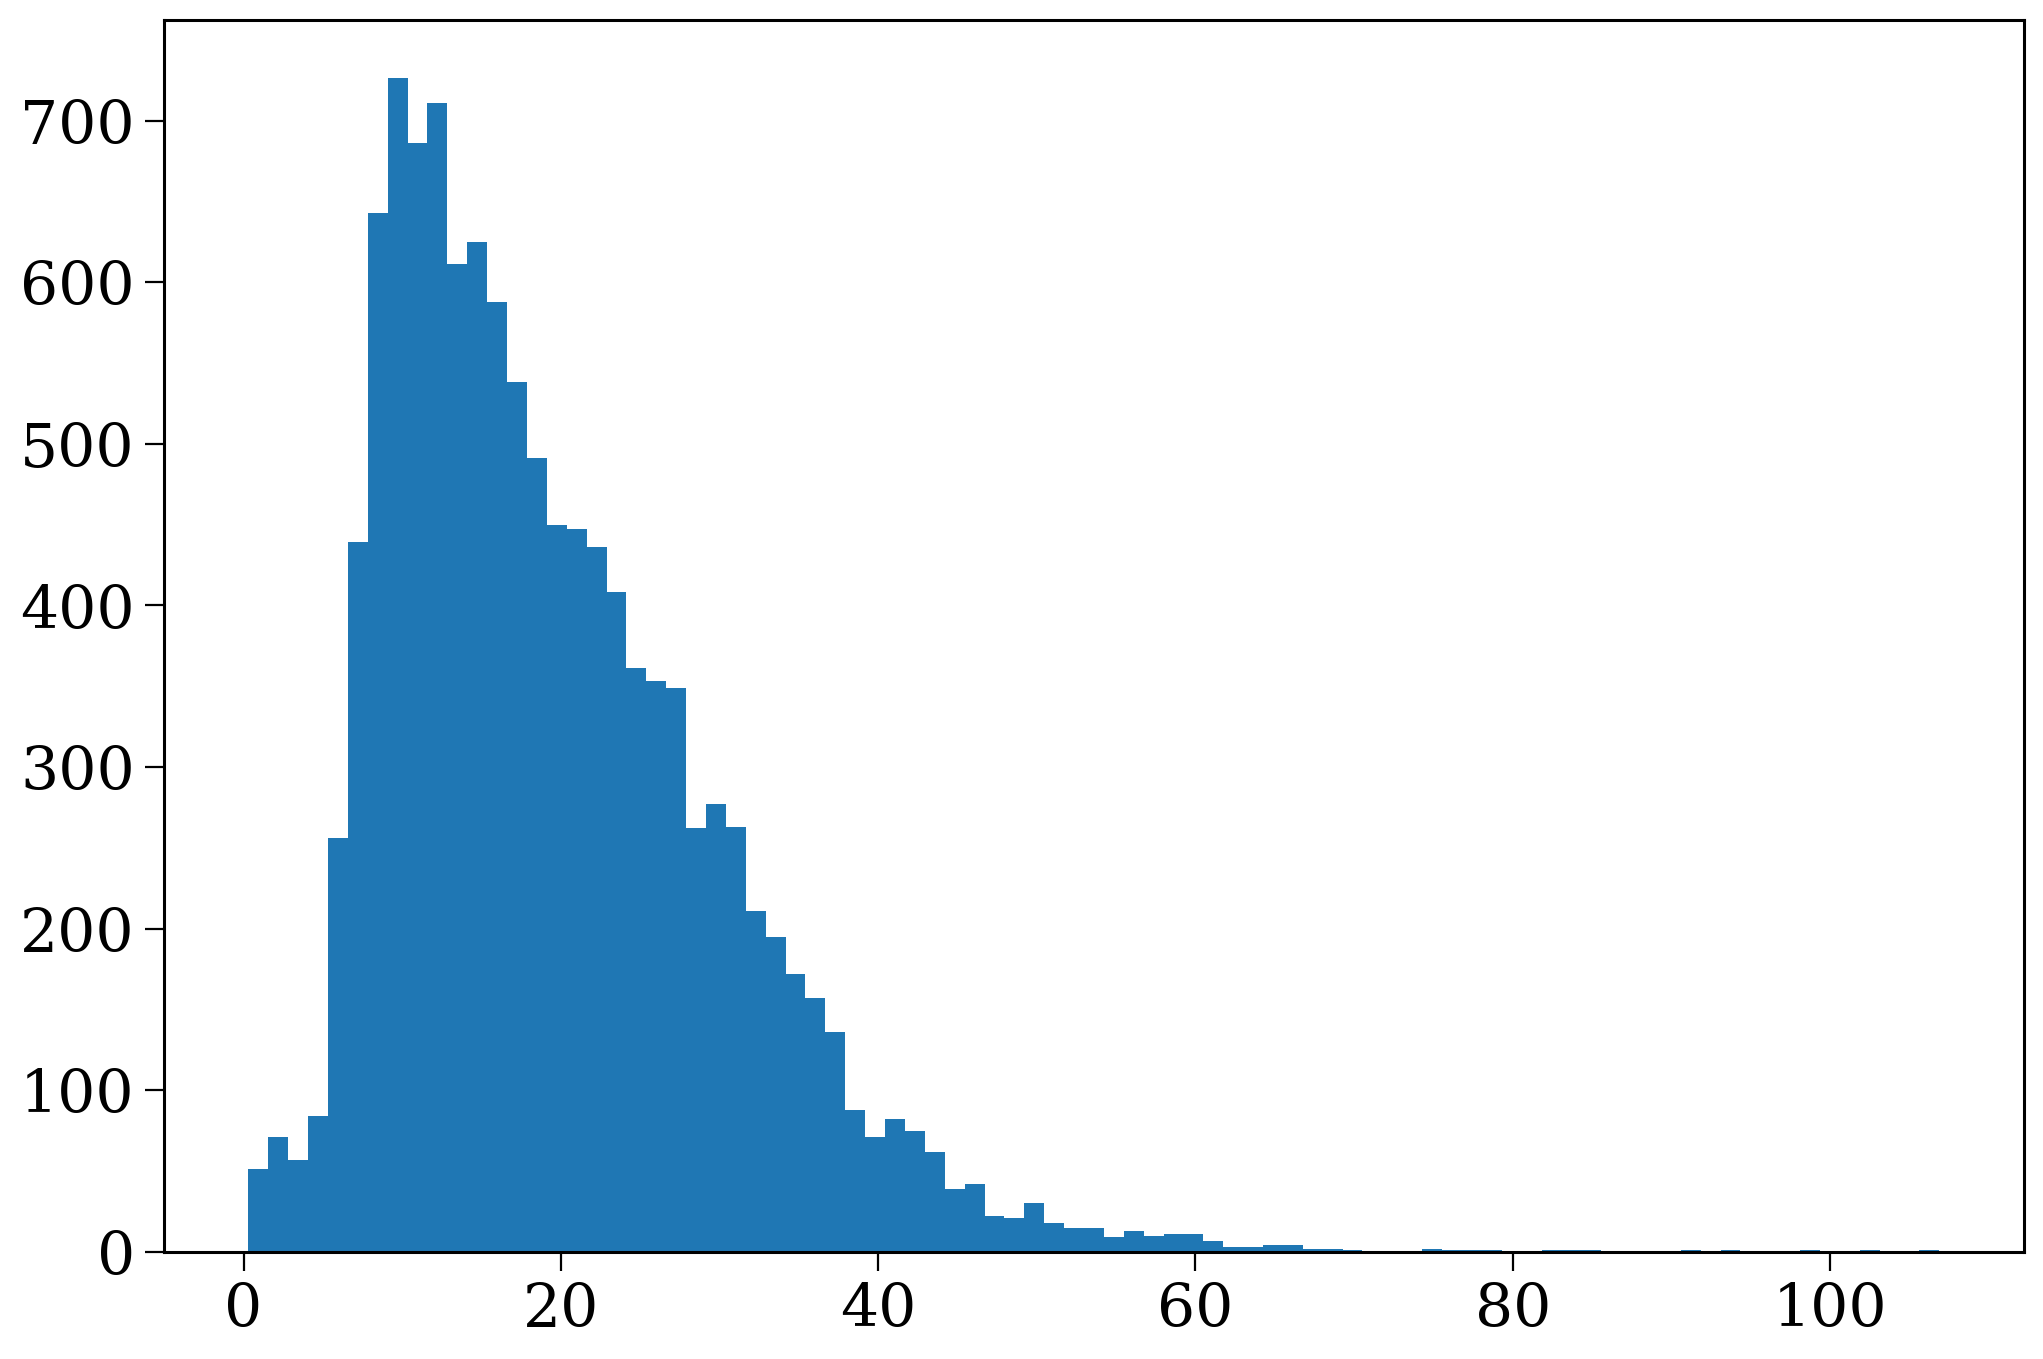

In [93]:
plt.hist(no_kicks.kick_info.loc[disrupted_ones].drop_duplicates(subset="bin_num", keep="last")["vsys_2_total"], bins="auto")